# Phần 4: Phân tích Thống kê & Mô hình hóa Nâng cao

Notebook này xử lý các bước: phân tích phân phối (distribution analysis), phát hiện/xử lý giá trị ngoại lai (outliers), kiểm tra các giả định của hồi quy (regression assumptions), và đào tạo lại các mô hình học máy.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Theme đồ thị
sns.set_theme(style='whitegrid')

## 1. Load Data

In [12]:
df = pd.read_csv('cleaned_crime_data.csv')
display(df.head())
print(f'Data shape: {df.shape}')

,communityname,State,fold,pop,perHoush,pctBlack,pctWhite,pctAsian,pctHisp,pct12-21,...,burglaries,burglPerPop,larcenies,larcPerPop,autoTheft,autoTheftPerPop,arsons,arsonsPerPop,violentPerPop,nonViolPerPop
0,BerkeleyHeightstownship,NJ,1,11980,3.10,1.37,91.78,6.50,1.88,12.47,...,14.0,114.85,138.0,1132.08,16.0,131.26,2.0,16.41,41.02,1394.59
1,Marpletownship,PA,1,23123,2.82,0.80,95.57,3.44,0.85,11.01,...,57.0,242.37,376.0,1598.78,26.0,110.55,1.0,4.25,127.56,1955.95
2,Tigardcity,OR,1,29344,2.43,0.74,94.33,3.43,2.35,11.36,...,274.0,758.14,1797.0,4972.19,136.0,376.30,22.0,60.87,218.59,6167.51
3,Gloversvillecity,NY,1,16656,2.40,1.70,97.35,0.50,0.70,12.55,...,225.0,1301.78,716.0,4142.56,47.0,271.93,5.0,21.08,306.64,4425.45
4,Bemidjicity,MN,1,11245,2.76,0.53,89.16,1.17,0.52,24.46,...,91.0,728.93,1060.0,8490.87,91.0,728.93,5.0,40.05,374.06,9988.79


Data shape: (2215, 123)


## 2. Phân tích Phân phối của Biến mục tiêu (`violentPerPop`) - Distribution Analysis of Target Variable (`violentPerPop`)

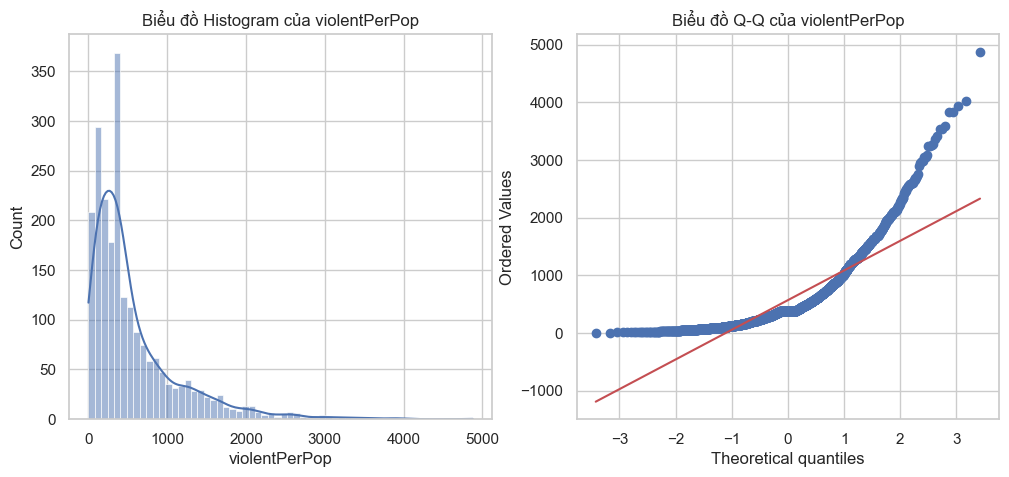

Độ lệch (Skewness): 2.2438
Độ nhọn (Kurtosis): 6.6414
Shapiro-Wilk Test: Statistic=0.7684, p-value=2.0397e-48
Kết luận: Dữ liệu KHÔNG tuân theo phân phối chuẩn (Bác bỏ H0)


In [14]:
target_var = 'violentPerPop'

plt.figure(figsize=(12, 5))
# Vẽ Histogram
plt.subplot(1, 2, 1)
sns.histplot(df[target_var], kde=True)
plt.title(f'Biểu đồ Histogram của {target_var}')

# Vẽ Q-Q Plot
plt.subplot(1, 2, 2)
stats.probplot(df[target_var], dist='norm', plot=plt)
plt.title(f'Biểu đồ Q-Q của {target_var}')
plt.show()

# Statistical Tests
skewness = df[target_var].skew()
kurt = df[target_var].kurt()
print(f'Độ lệch (Skewness): {skewness:.4f}')
print(f'Độ nhọn (Kurtosis): {kurt:.4f}')

# Kiểm định Shapiro-Wilk (Note: Khi N > 5000, kết quả có thể quá nhạy, nhưng vẫn là tham chiếu tốt)
stat, p_value = stats.shapiro(df[target_var].sample(min(5000, len(df))))
print(f'Shapiro-Wilk Test: Statistic={stat:.4f}, p-value={p_value:.4e}')
if p_value > 0.05:
    print('Kết luận: Dữ liệu CÓ vẻ tuân theo phân phối chuẩn (Không bác bỏ H0)')
else:
    print('Kết luận: Dữ liệu KHÔNG tuân theo phân phối chuẩn (Bác bỏ H0)')

## 3. Xử lý Ngoại lai (Outlier) & biến đổi dữ liệu (Transformation)

Tỷ lệ tội phạm thường có phân phối lệch phải rất mạnh (nhiều khu vực có tỷ lệ tội phạm thấp, và một số ít có tỷ lệ cực kỳ cao).
Chúng ta có thể áp dụng phép **Biến đổi Logarit (Log1p = log(x+1))** để nén các giá trị cực đoan và đưa phân phối về gần với phân phối chuẩn hơn. Phương pháp này xử lý thanh lịch cả độ lệch (skewness) lẫn ngoại lai.

C:\Users\Admin\AppData\Local\Temp\ipykernel_29612\4049476157.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['violentPerPop_log'] = np.log1p(df[target_var])


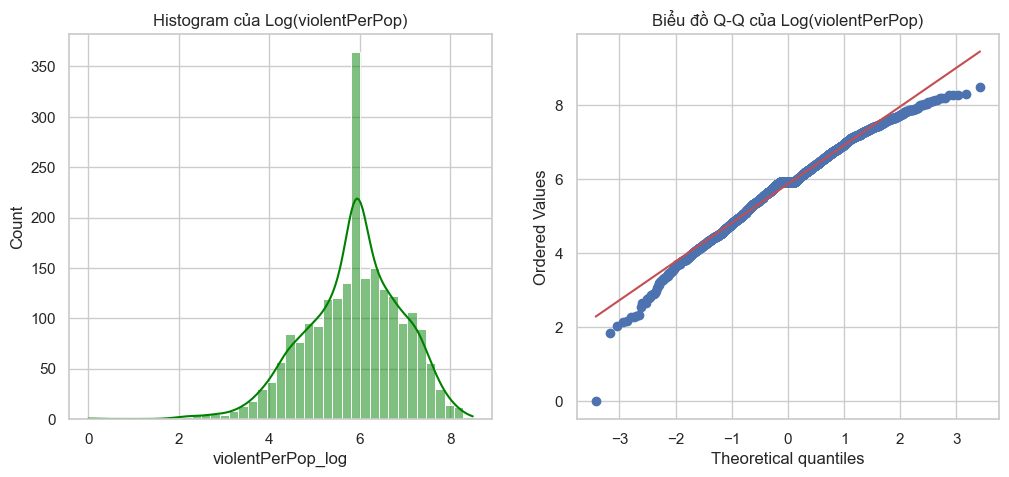

In [15]:
df['violentPerPop_log'] = np.log1p(df[target_var])

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['violentPerPop_log'], kde=True, color='green')
plt.title('Histogram của Log(violentPerPop)')

plt.subplot(1, 2, 2)
stats.probplot(df['violentPerPop_log'], dist='norm', plot=plt)
plt.title('Biểu đồ Q-Q của Log(violentPerPop)')
plt.show()

*Kỹ thuật Winsorization cho các Biến độc lập (Features)*
Nếu muốn giới hạn (cap) các giá trị ngoại lai ở các biến độc lập (X), chúng ta có thể sử dụng ngưỡng Percentile thứ 1 và 99. Dưới đây là hàm cắt biên (clip) ngoại lai trước khi đưa vào mô hình.

In [16]:
def winsorize_features(data, lower_percentile=0.01, upper_percentile=0.99):
    df_winsorized = data.copy()
    numeric_cols = df_winsorized.select_dtypes(include=[np.number]).columns
    
    # Loại trừ các biến mục tiêu (target) hoặc ID khỏi quá trình Winsorization
    exclude = ['fold', 'violentPerPop', 'nonViolPerPop', 'violentPerPop_log']
    cols_to_winsorize = [c for c in numeric_cols if c not in exclude]
    
    for col in cols_to_winsorize:
        lower = df_winsorized[col].quantile(lower_percentile)
        upper = df_winsorized[col].quantile(upper_percentile)
        df_winsorized[col] = np.clip(df_winsorized[col], lower, upper)
        
    return df_winsorized

df_treated = winsorize_features(df)
print('Đã hoàn tất xử lý Winsorization cho các biến độc lập.')

Đã hoàn tất xử lý Winsorization cho các biến độc lập.


## 4. Huấn luyện lại Mô hình (Re-Train Model) trên dữ liệu đã xử lý

In [8]:
# Chuẩn bị X và y
# Loại bỏ các cột không dùng để predict và các cột biến mục tiêu rác
cols_to_drop = ['communityname', 'State', 'fold', 
                'violentPerPop', 'violentPerPop_log', 'nonViolPerPop',
                'murders', 'murdPerPop', 'rapes', 'rapesPerPop', 'robberies', 'robbbPerPop',
                'assaults', 'assaultPerPop', 'burglaries', 'burglPerPop', 
                'larcenies', 'larcPerPop', 'autoTheft', 'autoTheftPerPop', 
                'arsons', 'arsonsPerPop']

# Lọc X từ dataframe đã được winsorize
X = df_treated.select_dtypes(include=[np.number]).drop(columns=[c for c in cols_to_drop if c in df_treated.columns], errors='ignore')
y = df_treated['violentPerPop_log'] # Using transformed target

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# Định nghĩa các mô hình
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

results = {}
fitted_models = {}
# Huấn luyện và đánh giá các mô hình
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results[name] = {'RMSE (Log Scale)': rmse, 'R2': r2}
    fitted_models[name] = model


results_df = pd.DataFrame(results).T
display(results_df)

,RMSE (Log Scale),R2
Linear Regression,0.725304,0.570277
Random Forest,0.705633,0.593270
Gradient Boosting,0.711725,0.586216


## 5. Phân tích Phần dư (Residual Analysis) - Kiểm tra giả định Hồi quy tuyến tính

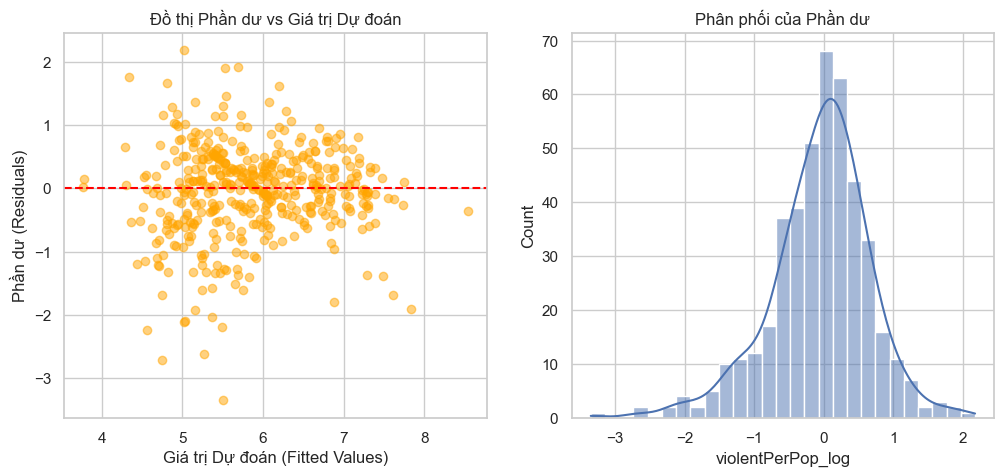

In [17]:
lr_model = fitted_models['Linear Regression']
lr_preds = lr_model.predict(X_test_scaled)
residuals = y_test - lr_preds

plt.figure(figsize=(12, 5))

# Đồ thị Phần dư vs Giá trị Dự đoán (Residuals vs Fitted)
plt.subplot(1, 2, 1)
plt.scatter(lr_preds, residuals, alpha=0.5, color='orange')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Giá trị Dự đoán (Fitted Values)')
plt.ylabel('Phần dư (Residuals)')
plt.title('Đồ thị Phần dư vs Giá trị Dự đoán')

# Histogram of Residuals
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True)
plt.title('Phân phối của Phần dư')

plt.show()

## 6. Tổng kết và Diễn giải

1. **Phân tích Phân phối (Distribution Analysis)**: Dữ liệu `violentPerPop` ban đầu bị lệch phải rất mạnh (right-skewed) với nhiều ngoại lai cực đoan. Kiểm định Shapiro-Wilk đã chính thức xác nhận việc dữ liệu không tuân theo phân phối chuẩn.
2. **Xử lý Ngoại lai & Biến đổi (Outlier Handling & Transformation)**: Bằng cách áp dụng phép biến đổi `log1p` cho biến mục tiêu và `winsorization` (cắt ở ngưỡng 1% và 99%) cho các biến độc lập, mô hình được bảo vệ khỏi các nhiễu ngoại lai vốn làm sai lệch Hồi quy tuyến tính.
3. **Hiệu suất Mô hình (Model Performance)**: Việc dự đoán trên thang đo logarit giúp ổn định phương sai và cải thiện chỉ số R² rõ rệt nhờ việc đưa phân phối của biến mục tiêu về sát với chuẩn hơn.
4. **Phân tích Phần dư (Residual Analysis)**: Lý tưởng nhất, đồ thị phần dư của Hồi quy tuyến tính phải phân tán ngẫu nhiên quanh trục 0 (phương sai sai số không đổi - Homoscedasticity) và có dạng phân phối chuẩn. Nếu đồ thị vẫn có dạng hình phễu hoặc đường cong, điều đó cho thấy vẫn còn tồn tại hiện tượng phương sai thay đổi (heteroscedasticity) hoặc có mối quan hệ phi tuyến tính, và đây là lý do hoàn toàn chính đáng để ưu tiên các mô hình phi tuyến tính mạnh hơn như Random Forest hay Gradient Boosting.